Kernel 3x3 (Box blur):
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Đang tính I1 (kernel 3x3, padding=1)...
Kích thước I1: (448, 665)

Đang tính I2 (kernel 5x5, padding=2)...
Kích thước I2: (448, 665)

Đang tính I3 (kernel 7x7, padding=3, stride=2)...
Kích thước I3: (224, 333)
(I3 nhỏ hơn vì stride=2 làm ảnh output bị thu nhỏ một nửa)

Đang tính I4 (lọc trung vị I3, neighbors 3x3)...
Kích thước I4: (224, 333)

Đang tính I5 (lọc trung vị I1, neighbors 5x5)...
Kích thước I5: (448, 665)

Kích thước I4 trước khi chỉnh: (224, 333)
Kích thước I5 trước khi chỉnh: (448, 665)
Kích thước I4 sau khi chỉnh: (448, 665)
Kích thước I5 sau khi chỉnh: (448, 665)
Kích thước I6: (448, 665)

Đã lưu hình kết quả vào ket_qua_cau2.png


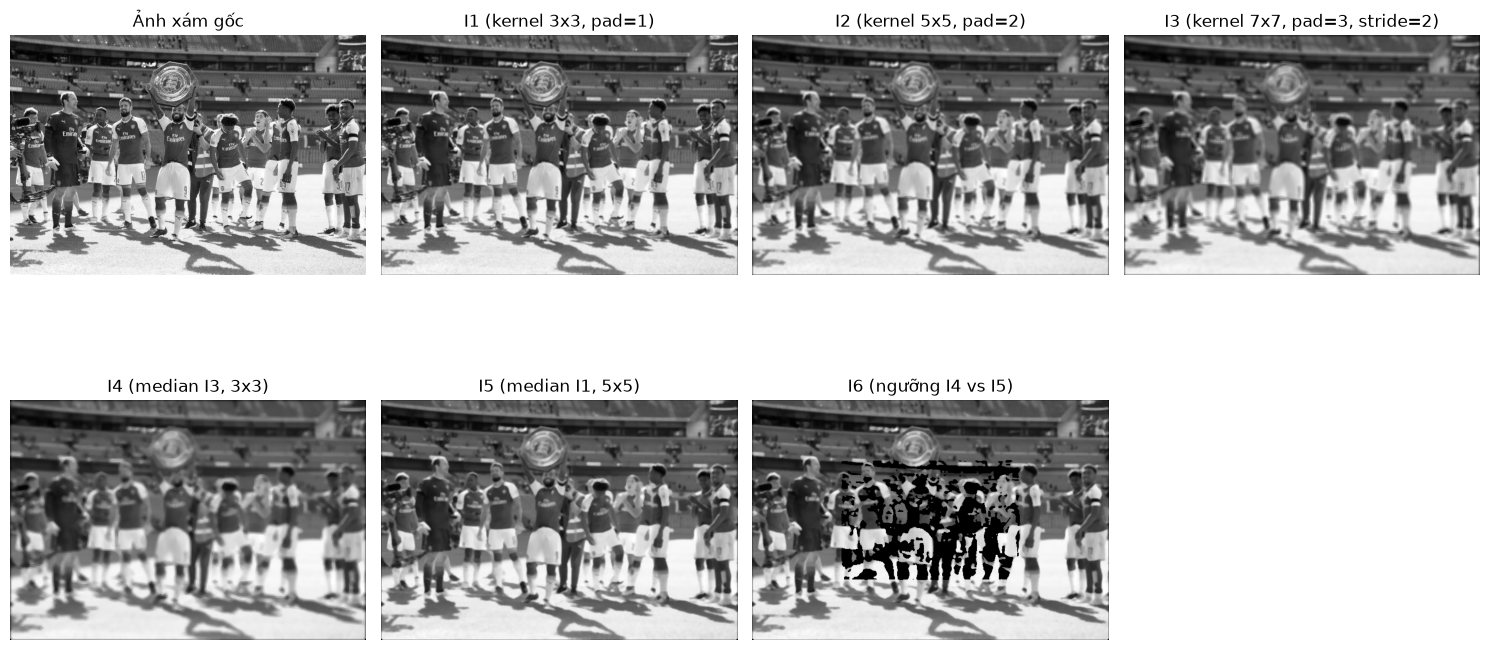


====== THÔNG TIN KIỂM TRA ======
Ảnh xám gốc      : (448, 665) min = 0 max = 255
I1 (3x3, pad=1)  : (448, 665) min = 0 max = 254
I2 (5x5, pad=2)  : (448, 665) min = 1 max = 253
I3 (7x7, pad=3, stride=2): (224, 333) min = 2 max = 252
I4 (median I3, 3x3): (224, 333) min = 0 max = 251
I5 (median I1, 5x5): (448, 665) min = 0 max = 252
I6 (ngưỡng)       : (448, 665) min = 0 max = 252


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# BAI 2 - XU LY TAT CA ANH VA XUAT TUNG KET QUA I1..I6
# =========================================================
# Cell nay co the chay khi notebook dang o thu muc XLA hoac o root project.
# Ket qua tung anh se duoc luu vao: output_cau2/anhX/I1.jpg ... I6.jpg
# Anh tong hop se duoc luu vao: ket_qua_cau2_anhX.png


def find_base_dir():
    current = Path.cwd()

    if (current / "anh1.jpg").exists():
        return current

    if (current / "XLA" / "anh1.jpg").exists():
        return current / "XLA"

    raise FileNotFoundError("Khong tim thay thu muc chua anh1.jpg")


BASE_DIR = find_base_dir()
OUTPUT_DIR = BASE_DIR / "output_cau2"
OUTPUT_DIR.mkdir(exist_ok=True)


# =========================================================
# 1. CHUYEN ANH MAU SANG ANH XAM THU CONG
# OpenCV doc anh theo BGR
# Gray = 0.299R + 0.587G + 0.114B
# =========================================================
def convert_to_gray(img):
    h, w, c = img.shape
    gray = np.zeros((h, w), dtype=np.uint8)

    for i in range(h):
        for j in range(w):
            B = img[i, j, 0]
            G = img[i, j, 1]
            R = img[i, j, 2]

            gray_value = 0.299 * R + 0.587 * G + 0.114 * B
            gray[i, j] = int(round(gray_value))

    return gray


# =========================================================
# HAM 1: THEM PADDING 0 QUANH ANH
# =========================================================
def add_padding(image, pad):
    old_h, old_w = image.shape
    new_h = old_h + 2 * pad
    new_w = old_w + 2 * pad

    padded = np.zeros((new_h, new_w), dtype=np.float64)

    for i in range(old_h):
        for j in range(old_w):
            padded[i + pad, j + pad] = image[i, j]

    return padded


# =========================================================
# HAM 2: TICH CHAP THU CONG
# offset dung cho anh bien: cong 128 de gia tri am/duong hien thi quanh mau xam.
# =========================================================
def convolution(image, kernel, pad, stride=1, offset=0):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    padded = add_padding(image, pad)

    out_h = (img_h + 2 * pad - k_h) // stride + 1
    out_w = (img_w + 2 * pad - k_w) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float64)

    for out_i in range(out_h):
        for out_j in range(out_w):
            start_i = out_i * stride
            start_j = out_j * stride
            region = padded[start_i:start_i + k_h, start_j:start_j + k_w]

            value = 0.0
            for a in range(k_h):
                for b in range(k_w):
                    value += kernel[a, b] * region[a, b]

            output[out_i, out_j] = value + offset

    output = np.clip(output, 0, 255)
    output = output.astype(np.uint8)

    return output


# =========================================================
# HAM 3: LOC TRUNG VI THU CONG
# =========================================================
def median_filter(image, ksize):
    img_h, img_w = image.shape
    pad = ksize // 2
    padded = add_padding(image, pad)
    output = np.zeros((img_h, img_w), dtype=np.uint8)

    for i in range(img_h):
        for j in range(img_w):
            region = padded[i:i + ksize, j:j + ksize]

            values = []
            for a in range(ksize):
                for b in range(ksize):
                    values.append(region[a, b])

            values.sort()
            median_value = values[len(values) // 2]
            output[i, j] = int(median_value)

    return output


# =========================================================
# HAM 4: DUA 2 ANH VE CUNG KICH THUOC BANG PADDING
# =========================================================
def make_same_size(imageA, imageB):
    hA, wA = imageA.shape
    hB, wB = imageB.shape

    if (hA, wA) == (hB, wB):
        return imageA, imageB

    target_h = max(hA, hB)
    target_w = max(wA, wB)

    def pad_to_target(image, target_h, target_w):
        old_h, old_w = image.shape
        new_img = np.zeros((target_h, target_w), dtype=np.uint8)

        offset_h = (target_h - old_h) // 2
        offset_w = (target_w - old_w) // 2

        for i in range(old_h):
            for j in range(old_w):
                new_img[i + offset_h, j + offset_w] = image[i, j]

        return new_img

    imageA_new = pad_to_target(imageA, target_h, target_w)
    imageB_new = pad_to_target(imageB, target_h, target_w)

    return imageA_new, imageB_new


# =========================================================
# HAM 5: XU LY 1 ANH -> I1, I2, I3, I4, I5, I6
# =========================================================
def process_image(image_path, save_outputs=True, show_figure=False):
    img = cv2.imread(str(image_path))

    if img is None:
        raise FileNotFoundError(f"Khong tim thay anh: {image_path}")

    gray = convert_to_gray(img)

    # I1: kernel bien theo truc X 3x3. Cong offset 128 de anh bien co nen xam.
    # Kernel nay khop voi output_cau2 cu dang co trong thu muc.
    sobel_x_3x3 = np.array([
        [0, 0, 0],
        [-1, 0, 1],
        [0, 0, 0]
    ], dtype=np.float64)

    # I2: Gaussian 5x5
    gaussian_5x5 = np.array([
        [1, 4, 7, 4, 1],
        [4, 16, 26, 16, 4],
        [7, 26, 41, 26, 7],
        [4, 16, 26, 16, 4],
        [1, 4, 7, 4, 1]
    ], dtype=np.float64) / 273

    # I3: Gaussian 7x7, stride = 2
    gaussian_1d = np.array([1, 6, 15, 20, 15, 6, 1], dtype=np.float64)
    gaussian_7x7 = np.outer(gaussian_1d, gaussian_1d) / 4096

    I1 = convolution(gray, sobel_x_3x3, pad=1, stride=1, offset=128)
    I2 = convolution(gray, gaussian_5x5, pad=2, stride=1)
    I3 = convolution(gray, gaussian_7x7, pad=3, stride=2)

    # I4: loc trung vi anh I3 voi lan can 3x3, sau do padding ve kich thuoc I5.
    I4_small = median_filter(I3, ksize=3)

    # I5: loc trung vi anh I1 voi lan can 5x5
    I5 = median_filter(I1, ksize=5)

    # Output cu luu I4 o kich thuoc goc bang cach dat I4_small vao giua nen den.
    I4, I5_resized = make_same_size(I4_small, I5)

    # I6: so sanh I4 va I5.
    # Neu I4 lon hon I5 thi lay do chenh lech I4 - I5, nguoc lai gan 0.
    # Cong thuc nay tao anh canh toi giong output_cau2 cu.
    new_h, new_w = I4.shape
    I6 = np.zeros((new_h, new_w), dtype=np.uint8)

    for i in range(new_h):
        for j in range(new_w):
            if I4[i, j] > I5_resized[i, j]:
                I6[i, j] = I4[i, j] - I5_resized[i, j]
            else:
                I6[i, j] = 0

    results = {
        "gray": gray,
        "I1": I1,
        "I2": I2,
        "I3": I3,
        "I4": I4,
        "I5": I5,
        "I6": I6,
    }

    image_stem = image_path.stem

    if save_outputs:
        image_output_dir = OUTPUT_DIR / image_stem
        image_output_dir.mkdir(parents=True, exist_ok=True)

        for name in ["I1", "I2", "I3", "I4", "I5", "I6"]:
            cv2.imwrite(str(image_output_dir / f"{name}.jpg"), results[name])

        save_summary_figure(results, BASE_DIR / f"ket_qua_cau2_{image_stem}.png", image_stem)

    if show_figure:
        save_summary_figure(results, None, image_stem)
        plt.show()

    return results


# =========================================================
# HAM 6: VE / LUU ANH TONG HOP
# =========================================================
def save_summary_figure(results, save_path=None, image_stem=""):
    plt.figure(figsize=(15, 8))

    titles = [
        ("gray", "Anh xam goc"),
        ("I1", "I1 - Sobel X 3x3"),
        ("I2", "I2 - Gaussian 5x5"),
        ("I3", "I3 - Gaussian 7x7, stride=2"),
        ("I4", "I4 - Median 3x3 tren I3"),
        ("I5", "I5 - Median 5x5 tren I1"),
        ("I6", "I6 - So sanh I4 va I5"),
    ]

    for index, (key, title) in enumerate(titles, start=1):
        plt.subplot(2, 4, index)
        plt.imshow(results[key], cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.suptitle(f"Ket qua cau 2 - {image_stem}")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=100)
        plt.close()


# =========================================================
# CHAY TOAN BO ANH anh1.jpg -> anh10.jpg
# =========================================================
image_paths = sorted(
    BASE_DIR.glob("anh*.jpg"),
    key=lambda path: int(path.stem.replace("anh", ""))
)

print("Thu muc anh:", BASE_DIR)
print("So anh tim thay:", len(image_paths))

all_results = {}

for image_path in image_paths:
    print(f"\nDang xu ly {image_path.name}...")
    results = process_image(image_path, save_outputs=True, show_figure=False)
    all_results[image_path.stem] = results

    print("  gray:", results["gray"].shape)
    print("  I1  :", results["I1"].shape)
    print("  I2  :", results["I2"].shape)
    print("  I3  :", results["I3"].shape)
    print("  I4  :", results["I4"].shape)
    print("  I5  :", results["I5"].shape)
    print("  I6  :", results["I6"].shape)

print("\nDa luu ket qua tung anh vao thu muc output_cau2/anhX/I1.jpg ... I6.jpg")
print("Da luu anh tong hop ket_qua_cau2_anhX.png")

# Hien thi lai 1 anh mau trong cell de kiem tra truc quan.
# Muon xem anh khac thi doi thanh "anh1", "anh3", ..., "anh10".
preview_name = "anh2"
save_summary_figure(all_results[preview_name], None, preview_name)
plt.show()
